# Smart Recruitment Assistant

## Overview
Modern hiring pipelines receive far more applications than teams can manually screen,
making it easy for strong candidates to get lost in the volume. This project builds a
classification system that predicts whether a candidate is likely to advance in the
hiring process, using the **HR Analytics: Job Change of Data Scientists** dataset as a
proxy; candidates actively looking to change jobs (`target = 1`) are treated as those
worth prioritizing for outreach or advancement.

## Approach
Classification models (Logistic Regression, Decision Tree, Random Forest, KNN, SVM,
and XGBoost) are trained on a shared preprocessing pipeline and compared on ROC-AUC,
precision, and recall with particular attention to the dataset's class imbalance
(~75% not looking, ~25% looking) and its mix of numeric, ordinal, and nominal features.

The best-performing model is saved for reuse and tested against unseen candidate data.

## Notebook Structure
`Imports` → `Load Data` → `EDA` → `Preprocessing` → `Modeling` → `Evaluation` → `Conclusion`

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import joblib

import warnings
warnings.filterwarnings("ignore")

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Load Data

In [2]:
train = pd.read_csv('aug_train.csv')
test = pd.read_csv('aug_test.csv')

print('Train shape:', train.shape)
print('Test shape:', test.shape)
train.head()

Train shape: (19158, 14)
Test shape: (2129, 13)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Data Overview

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  str    
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  last_new_job            18735 non-null  str    
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), str(10)
memory usage: 3.

In [4]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
enrollee_id,19158.0,NaN,NaN,NaN,16875.358179,9616.292592,1.0,8554.25,16982.5,25169.75,33380.0
city,19158,123,city_103,4355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_development_index,19158.0,NaN,NaN,NaN,0.828848,0.123362,0.448,0.74,0.903,0.92,0.949
gender,14650,3,Male,13221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relevent_experience,19158,2,Has relevent experience,13792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enrolled_university,18772,3,no_enrollment,13817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,18698,5,Graduate,11598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major_discipline,16345,6,STEM,14492,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience,19093,22,>20,3286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,13220,8,50-99,3083,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Missing Values

In [5]:
info = pd.DataFrame({
    'dtype': train.dtypes,
    'missing_count': train.isnull().sum(),
    'missing_pct': (train.isnull().sum() / len(train) * 100).round(2),
    'n_unique': train.nunique()
})
info.sort_values('missing_pct', ascending=False)

,dtype,missing_count,missing_pct,n_unique
company_type,str,6140,32.05,6
company_size,str,5938,30.99,8
gender,str,4508,23.53,3
major_discipline,str,2813,14.68,6
education_level,str,460,2.40,5
last_new_job,str,423,2.21,6
enrolled_university,str,386,2.01,3
experience,str,65,0.34,22
enrollee_id,int64,0,0.00,19158
city,str,0,0.00,123


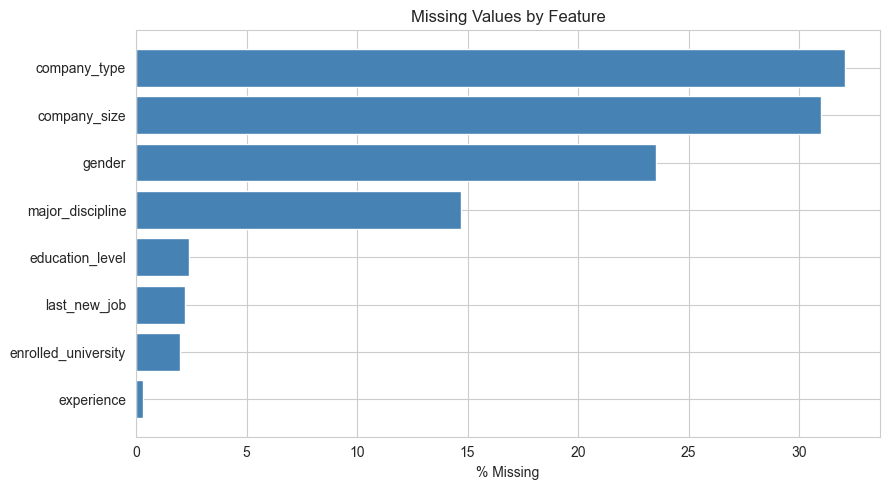

In [6]:
fig, ax = plt.subplots(figsize=(9,5))
missing_pct = info[info['missing_pct'] > 0].sort_values('missing_pct')
ax.barh(missing_pct.index, missing_pct['missing_pct'], color='steelblue')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Feature')
plt.tight_layout()
plt.show()

### 3.3 Target Distribution

target
0.0    75.065247
1.0    24.934753
Name: proportion, dtype: float64


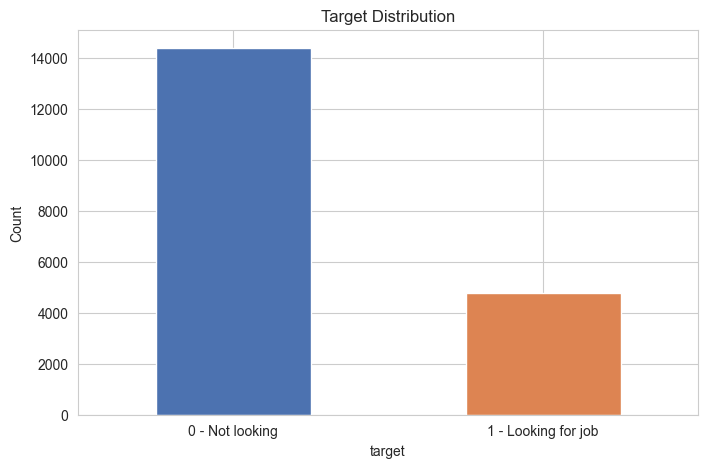

In [7]:
target_counts = train['target'].value_counts(normalize=True) * 100
print(target_counts)

fig, ax = plt.subplots()
train['target'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452'], ax=ax)
ax.set_xticklabels(['0 - Not looking', '1 - Looking for job'], rotation=0)
ax.set_title('Target Distribution')
ax.set_ylabel('Count')
plt.show()

### 3.4 Numerical Features

In [8]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
enrollee_id,19158.0,16875.358179,9616.292592,1.000,8554.25,16982.500,25169.75,33380.000
city_development_index,19158.0,0.828848,0.123362,0.448,0.74,0.903,0.92,0.949
training_hours,19158.0,65.366896,60.058462,1.000,23.00,47.000,88.00,336.000
target,19158.0,0.249348,0.432647,0.000,0.00,0.000,0.00,1.000


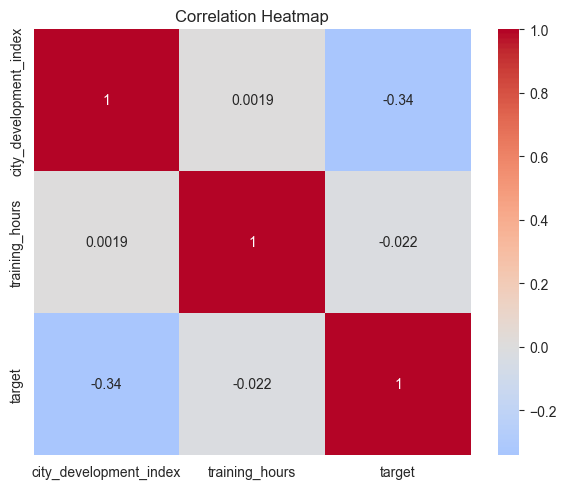

In [9]:
fig, ax = plt.subplots(figsize=(6,5))
corr = train[['city_development_index', 'training_hours', 'target']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### 3.5 Categorical Features vs Target

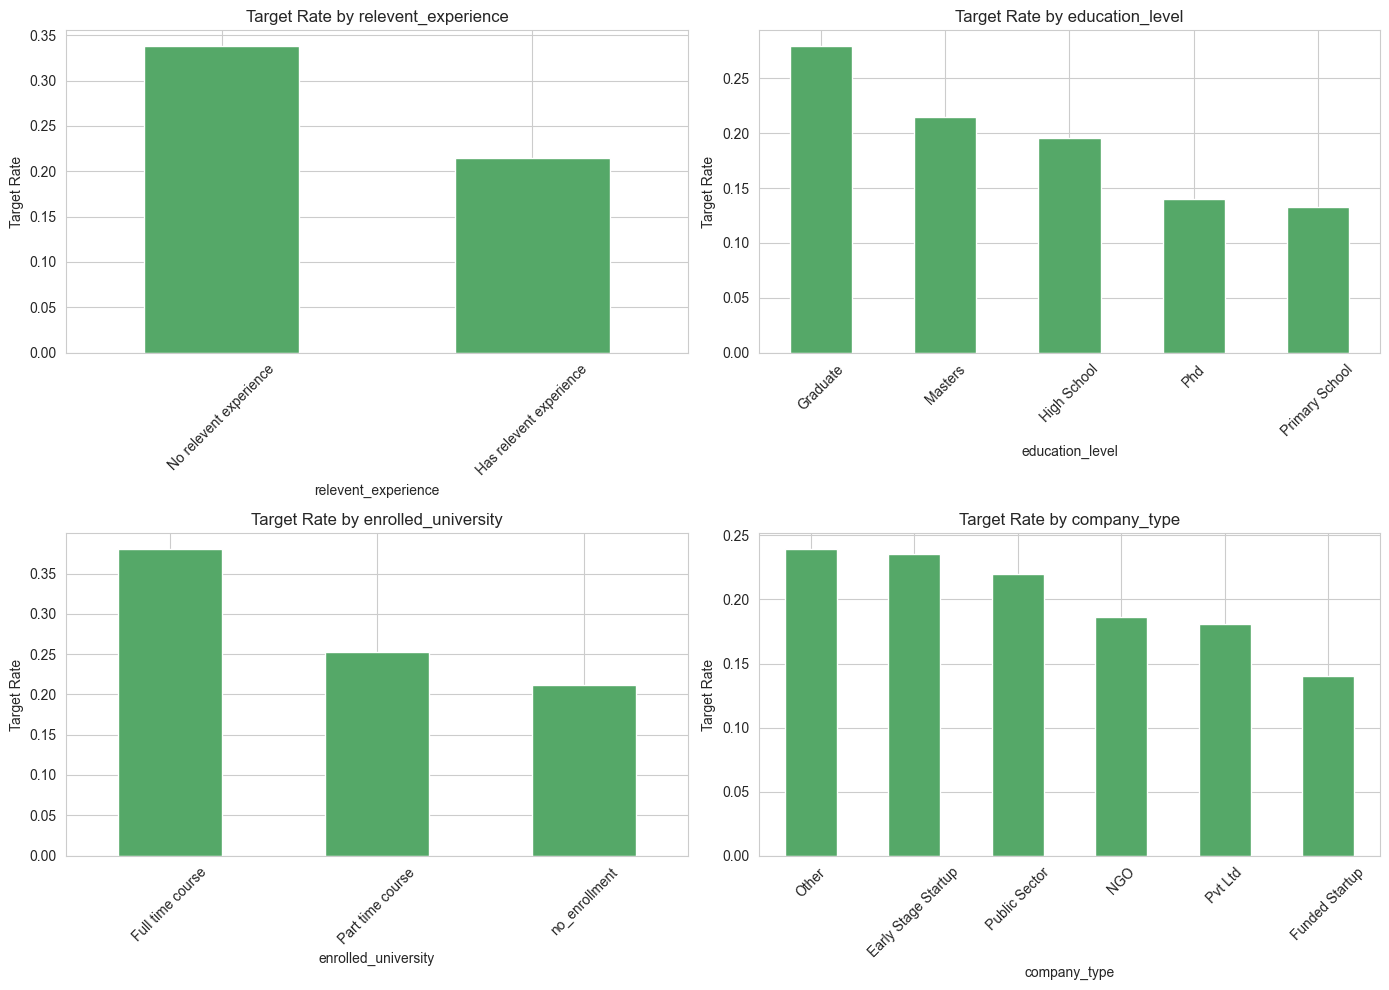

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cat_cols = ['relevent_experience', 'education_level', 'enrolled_university', 'company_type']
for ax, col in zip(axes.flatten(), cat_cols):
    rates = train.groupby(col)['target'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='#55A868')
    ax.set_title(f'Target Rate by {col}')
    ax.set_ylabel('Target Rate')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [11]:
print('Unique cities:', train['city'].nunique())
train['city'].value_counts().head(10)

Unique cities: 123


city
city_103    4355
city_21     2702
city_16     1533
city_114    1336
city_160     845
city_136     586
city_67      431
city_75      305
city_102     304
city_104     301
Name: count, dtype: int64

## 4. Preprocessing Pipeline

All cleaning, encoding, and scaling steps are wrapped inside a single pipeline object.
This pipeline is fitted only on the training data, and the exact same fitted steps
can then be applied to any new incoming test file, without repeating any code manually.

### 4.1 Custom Cleaning Step

In [12]:
class ExperienceCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['experience'] = X['experience'].replace({'>20': '21', '<1': '0'})
        X['experience'] = pd.to_numeric(X['experience'])

        X['last_new_job'] = X['last_new_job'].replace({'never': '0', '>4': '5'})
        X['last_new_job'] = pd.to_numeric(X['last_new_job'])
        return X

### 4.2 Feature Engineering Step

In [13]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X['no_company_info'] = (X['company_size'].isna() & X['company_type'].isna()).astype(int)

        X['job_change_rate'] = X['last_new_job'] / (X['experience'] + 1)

        X['training_intensity'] = X['training_hours'] / (X['experience'] + 1)

        return X

### 4.3 Column Transformer (Imputation, Encoding, Scaling)

In [14]:
numeric_features = ['city_development_index', 'training_hours', 'experience', 'last_new_job']
ordinal_features = ['education_level', 'company_size']
nominal_features = ['gender', 'relevent_experience', 'enrolled_university', 'major_discipline', 'company_type']

education_order = ['Unknown', 'Primary School', 'High School', 'Graduate', 'Masters', 'Phd']
company_size_order = ['Unknown', '<10', '10/49', '50-99', '100-500', '500-999',
                       '1000-4999', '5000-9999', '10000+']

In [15]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OrdinalEncoder(categories=[education_order, company_size_order],
                                handle_unknown='use_encoded_value', unknown_value=-1))
])

nominal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

numeric_features = numeric_features + ['no_company_info', 'job_change_rate', 'training_intensity']

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('ord', ordinal_transformer, ordinal_features),
    ('nom', nominal_transformer, nominal_features)
])

Columns not listed in the transformer (`enrollee_id`, `city`) are dropped automatically,
since `city` is fully redundant with `city_development_index`, and `enrollee_id` is only an identifier.

### 4.4 Train-Validation Split

In [16]:
X = train.drop(columns=['target'])
y = train['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print('X_train shape:', X_train.shape)
print('X_val shape:', X_val.shape)

X_train shape: (15326, 13)
X_val shape: (3832, 13)


## 5. Modeling

### 5.1 Classification Models

In [17]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                              random_state=42, eval_metric='auc'),
    'LightGBM': LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                random_state=42, verbose=-1)
}

### 5.2 Models Comparison

In [18]:
fitted_models = {}
results = {}

for name, model in models.items():
    clf = ImbPipeline(steps=[
        ('experience_cleaner', ExperienceCleaner()),
        ('feature_engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    clf.fit(X_train, y_train)
    fitted_models[name] = clf

    preds = clf.predict(X_val)
    probs = clf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, probs)
    results[name] = auc

    print(f"\n=== {name} (AUC = {auc:.3f}) ===")
    print(classification_report(y_val, preds))


=== LogisticRegression (AUC = 0.790) ===
              precision    recall  f1-score   support

         0.0       0.91      0.72      0.80      2877
         1.0       0.48      0.78      0.59       955

    accuracy                           0.73      3832
   macro avg       0.69      0.75      0.70      3832
weighted avg       0.80      0.73      0.75      3832


=== DecisionTree (AUC = 0.639) ===
              precision    recall  f1-score   support

         0.0       0.82      0.77      0.80      2877
         1.0       0.42      0.50      0.46       955

    accuracy                           0.71      3832
   macro avg       0.62      0.64      0.63      3832
weighted avg       0.72      0.71      0.71      3832


=== RandomForest (AUC = 0.795) ===
              precision    recall  f1-score   support

         0.0       0.86      0.84      0.85      2877
         1.0       0.55      0.58      0.56       955

    accuracy                           0.78      3832
   macro avg  

In [19]:
results_df = pd.DataFrame(results.items(), columns=['Model', 'AUC']).sort_values('AUC', ascending=False)
results_df

,Model,AUC
6,LightGBM,0.813102
5,XGBoost,0.811665
4,SVM,0.802925
2,RandomForest,0.794961
0,LogisticRegression,0.789610
3,KNN,0.729293
1,DecisionTree,0.638833


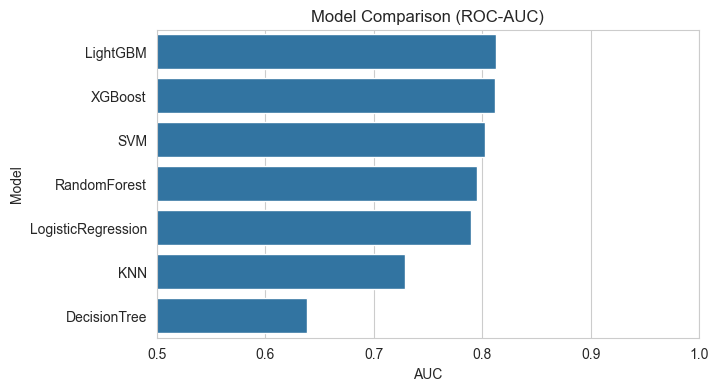

In [20]:
plt.figure(figsize=(7,4))
sns.barplot(data=results_df, x='AUC', y='Model')
plt.title('Model Comparison (ROC-AUC)')
plt.xlim(0.5, 1.0)
plt.show()

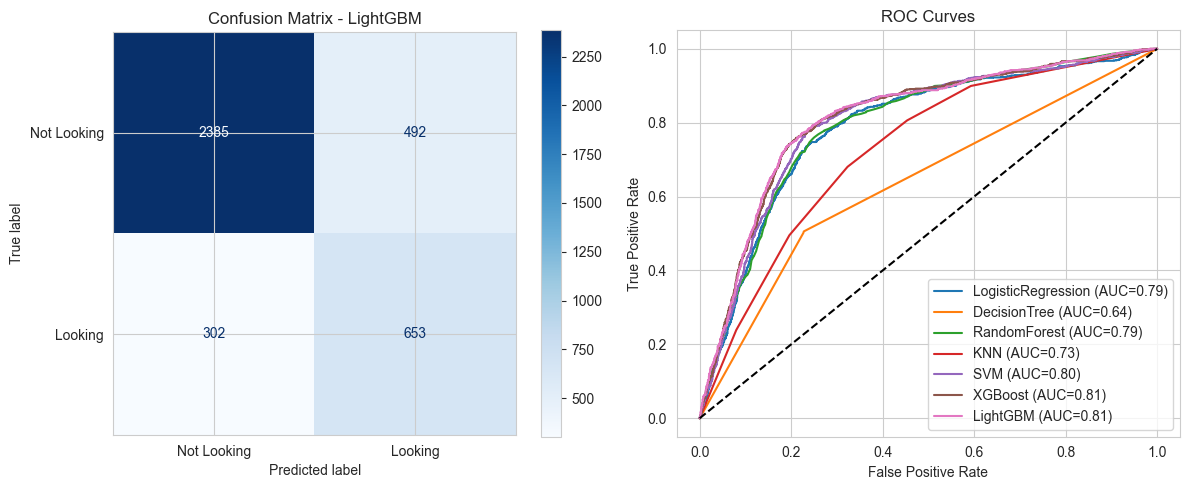

In [21]:
best_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_val, best_model.predict(X_val))
ConfusionMatrixDisplay(cm, display_labels=['Not Looking', 'Looking']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix - {best_name}')

for name, clf in fitted_models.items():
    probs = clf.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, probs)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={results[name]:.2f})')

axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning

The three strongest performers from the comparison above (Random Forest,LightGBM, XGBoost, and SVM) are tuned further
using `RandomizedSearchCV` over the imbalanced pipeline (cleaning, feature engineering, preprocessing, SMOTE,
classifier). Randomized search is preferred over an exhaustive grid here since the parameter spaces are wide
and a full grid would be too expensive to run for three separate models.

In [22]:
param_distributions = {
    'RandomForest': {
        'classifier__n_estimators': [200, 300, 400, 500],
        'classifier__max_depth': [None, 8, 12, 16, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__max_features': ['sqrt', 'log2', 0.5],
        'classifier__bootstrap': [True, False]
    },

    'LightGBM': {
        'classifier__n_estimators': [150, 250, 350, 450],
        'classifier__num_leaves': [15, 31, 47, 63],
        'classifier__max_depth': [-1, 4, 6, 8],
        'classifier__learning_rate': [0.01, 0.03, 0.05, 0.08],
        'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
        'classifier__colsample_bytree': [0.6, 0.8, 1.0],
        'classifier__reg_lambda': [0.0, 0.5, 1.0, 5.0]
    },

    'XGBoost': {
        'classifier__n_estimators': [150, 250, 350, 450],
        'classifier__max_depth': [3, 4, 5, 6, 7],
        'classifier__learning_rate': [0.01, 0.03, 0.05, 0.08],
        'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
        'classifier__colsample_bytree': [0.6, 0.8, 1.0],
        'classifier__gamma': [0, 0.1, 0.3, 0.5],
        'classifier__reg_lambda': [0.5, 1.0, 3.0, 5.0]
    },

    'SVM': {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__gamma': ['scale', 'auto', 0.01, 0.1],
        'classifier__kernel': ['rbf']
    }
}

n_iterations = {
    'RandomForest': 25,
    'LightGBM': 25,
    'XGBoost': 25,
    'SVM': 8
}

In [23]:
tuned_models = {}
tuning_results = {}

for name in ['RandomForest', 'LightGBM', 'XGBoost', 'SVM']:
    base_pipeline = ImbPipeline(steps=[
        ('experience_cleaner', ExperienceCleaner()),
        ('feature_engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', models[name])
    ])

    search = RandomizedSearchCV(
        estimator=base_pipeline,
        param_distributions=param_distributions[name],
        n_iter=n_iterations[name],
        scoring='roc_auc',
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train, y_train)

    tuned_models[name] = search.best_estimator_

    val_probs = search.best_estimator_.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_probs)

    tuning_results[name] = {
        'cv_best_auc': search.best_score_,
        'val_auc_before': results[name],
        'val_auc_after': val_auc,
        'best_params': search.best_params_
    }

    print(f"\n=== {name} ===")
    print(f"Best CV AUC: {search.best_score_:.4f}")
    print(f"Validation AUC before tuning: {results[name]:.4f}")
    print(f"Validation AUC after tuning:  {val_auc:.4f}")
    print(f"Best params: {search.best_params_}")


=== RandomForest ===
Best CV AUC: 0.7938
Validation AUC before tuning: 0.7950
Validation AUC after tuning:  0.8058
Best params: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': 16, 'classifier__bootstrap': True}

=== LightGBM ===
Best CV AUC: 0.7971
Validation AUC before tuning: 0.8131
Validation AUC after tuning:  0.8143
Best params: {'classifier__subsample': 0.7, 'classifier__reg_lambda': 5.0, 'classifier__num_leaves': 31, 'classifier__n_estimators': 250, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.6}

=== XGBoost ===
Best CV AUC: 0.7956
Validation AUC before tuning: 0.8117
Validation AUC after tuning:  0.8121
Best params: {'classifier__subsample': 0.9, 'classifier__reg_lambda': 5.0, 'classifier__n_estimators': 150, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0, 'classifier__c

### 6.1 Tuned vs Untuned Comparison

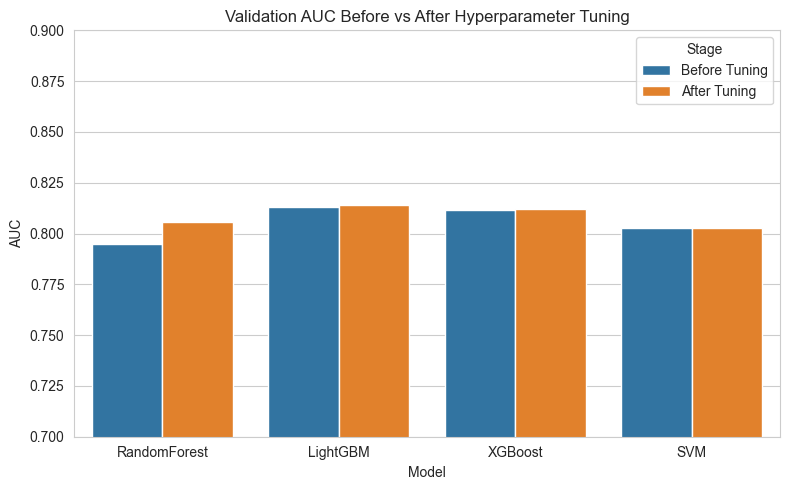

In [24]:
tuning_df = pd.DataFrame([
    {'Model': name, 'AUC': info['val_auc_before'], 'Stage': 'Before Tuning'}
    for name, info in tuning_results.items()
] + [
    {'Model': name, 'AUC': info['val_auc_after'], 'Stage': 'After Tuning'}
    for name, info in tuning_results.items()
])

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=tuning_df, x='Model', y='AUC', hue='Stage', ax=ax)
ax.set_ylim(0.7, 0.9)
ax.set_title('Validation AUC Before vs After Hyperparameter Tuning')
plt.tight_layout()
plt.show()

### 6.2 Tuned Models vs Full Original Lineup

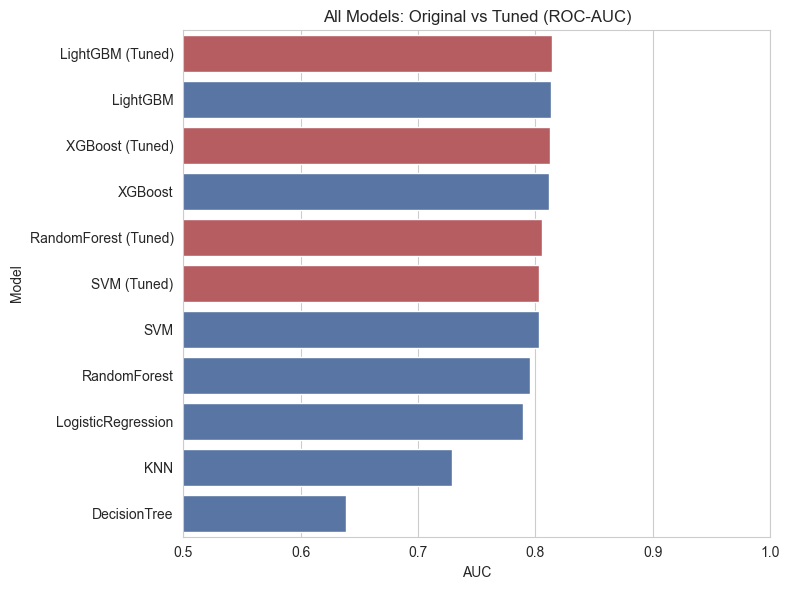

,Model,AUC
8,LightGBM (Tuned),0.814294
6,LightGBM,0.813102
9,XGBoost (Tuned),0.812143
5,XGBoost,0.811665
7,RandomForest (Tuned),0.805750
10,SVM (Tuned),0.802954
4,SVM,0.802925
2,RandomForest,0.794961
0,LogisticRegression,0.789610
3,KNN,0.729293


In [25]:
final_results = dict(results)
for name, info in tuning_results.items():
    final_results[f'{name} (Tuned)'] = info['val_auc_after']

final_results_df = pd.DataFrame(final_results.items(), columns=['Model', 'AUC']).sort_values('AUC', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#C44E52' if '(Tuned)' in m else '#4C72B0' for m in final_results_df['Model']]
sns.barplot(data=final_results_df, x='AUC', y='Model', palette=colors, ax=ax)
ax.set_xlim(0.5, 1.0)
ax.set_title('All Models: Original vs Tuned (ROC-AUC)')
plt.tight_layout()
plt.show()

final_results_df

Best tuned model: LightGBM
              precision    recall  f1-score   support

         0.0       0.91      0.80      0.85      2877
         1.0       0.55      0.76      0.64       955

    accuracy                           0.79      3832
   macro avg       0.73      0.78      0.74      3832
weighted avg       0.82      0.79      0.80      3832



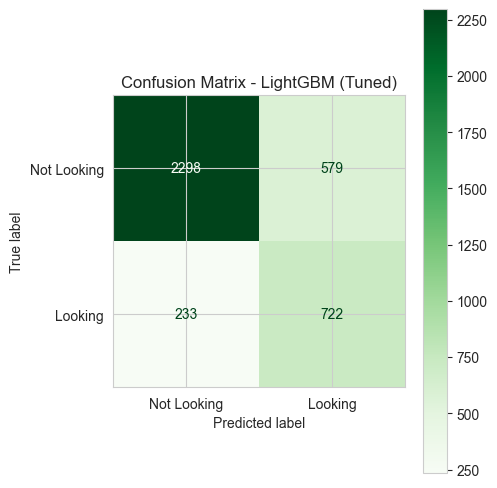

In [26]:
best_tuned_name = max(tuning_results, key=lambda n: tuning_results[n]['val_auc_after'])
best_tuned_model = tuned_models[best_tuned_name]

print(f"Best tuned model: {best_tuned_name}")
print(classification_report(y_val, best_tuned_model.predict(X_val)))

cm_tuned = confusion_matrix(y_val, best_tuned_model.predict(X_val))
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm_tuned, display_labels=['Not Looking', 'Looking']).plot(ax=ax, cmap='Greens')
ax.set_title(f'Confusion Matrix - {best_tuned_name} (Tuned)')
plt.tight_layout()
plt.show()

## 7. Threshold Analysis (Precision / Recall trade-off)

So far every confusion matrix / classification report above used the default 0.5 probability threshold. For an HR screening use case, the cost of a false negative (missing a candidate who is actually about to leave) is usually different from the cost of a false positive (flagging a candidate who was not actually looking). The plot below shows how precision and recall trade off as the threshold changes for the best tuned model, on the held-out validation set, so a threshold can be chosen deliberately instead of defaulting to 0.5.

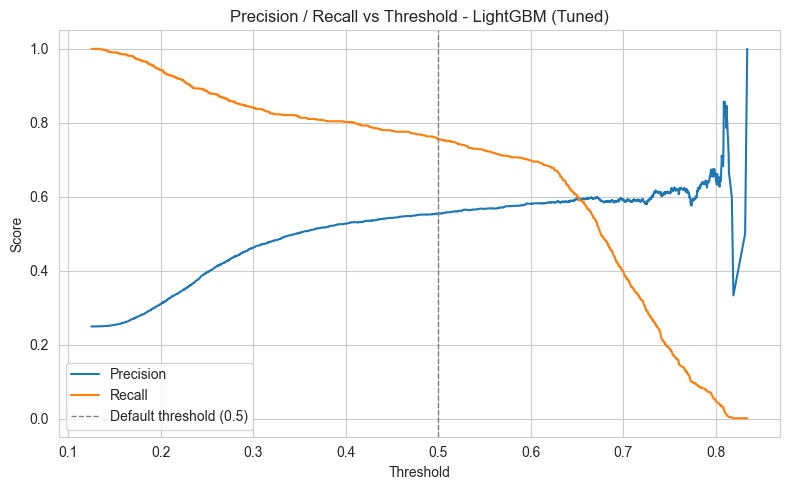

Example: at threshold 0.5 -> default classification_report shown earlier.
Adjust the threshold above based on the actual cost of false positives vs false negatives
for this recruitment use case before deploying.


In [27]:
from sklearn.metrics import precision_recall_curve

val_probs_best = best_tuned_model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs_best)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions[:-1], label='Precision')
ax.plot(thresholds, recalls[:-1], label='Recall')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Precision / Recall vs Threshold - {best_tuned_name} (Tuned)')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Default threshold (0.5)')
ax.legend()
plt.tight_layout()
plt.show()

print("Example: at threshold 0.5 -> default classification_report shown earlier.")
print("Adjust the threshold above based on the actual cost of false positives vs false negatives")
print("for this recruitment use case before deploying.")


## 8. Final Model: Refit on Full Training Data & Predict on `aug_test.csv`

A test file should be processed through the same fitted pipeline used for training, not handled with separate logic.

Here, we take the same best_tuned_model pipeline (cleaning, feature engineering, preprocessing, SMOTE, and the classifier with the best hyperparameters from RandomizedSearchCV), refit it from scratch on the full training data (100%, not just the 80% split it was trained on), and then apply it as-is to aug_test.csv.

This is the same principle that should apply to any new test file going forward: fit the pipeline once on all available training data, then reuse that same fitted pipeline (fit only once) on any new test data, never refit it on the test data itself.

In [28]:
from sklearn.base import clone

# Rebuild an unfitted copy of the best tuned pipeline (same steps + same best hyperparameters),
# then refit it on the FULL training set (100% of aug_train.csv) instead of just the 80% split.
final_pipeline = clone(best_tuned_model)
final_pipeline.fit(X, y)

print(f"Final pipeline ({best_tuned_name}) refit on the full training set: {X.shape[0]} rows.")


Final pipeline (LightGBM) refit on the full training set: 19158 rows.


In [31]:
X_encoded = final_pipeline.named_steps['preprocessor'].transform(
    final_pipeline.named_steps['feature_engineer'].transform(
        final_pipeline.named_steps['experience_cleaner'].transform(X)
    )
)
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
X_encoded_df = pd.DataFrame(X_encoded, columns=feature_names)
X_encoded_df.to_csv('train_encoded_features.csv', index=False)
print(X_encoded_df.shape)

(19158, 33)


In [ ]:
test_probs = final_pipeline.predict_proba(test)[:, 1]

submission = pd.DataFrame({
    'enrollee_id': test['enrollee_id'],
    'target': test_probs
})

submission.to_csv('submission.csv', index=False)

print('submission.csv shape:', submission.shape)
submission.head()


submission.csv shape: (2129, 2)


,enrollee_id,target
0,32403,0.250068
1,9858,0.337006
2,31806,0.655487
3,27385,0.201175
4,27724,0.200677


### 8.1 Save the Fitted Pipeline for Reuse

`joblib` was already imported in Section 1 but never used. Saving the fitted pipeline means any future test file with the same raw columns can be scored later (e.g. in production) by loading this file and calling `.predict_proba()` directly, without repeating any of the cleaning/encoding/SMOTE/model code above.

In [30]:
joblib.dump(final_pipeline, 'final_pipeline.joblib')
print("Saved fitted pipeline to final_pipeline.joblib")

# Example of how it would be reused later on any new test file with the same raw columns:
# loaded_pipeline = joblib.load('final_pipeline.joblib')
# new_probs = loaded_pipeline.predict_proba(new_test_df)[:, 1]


Saved fitted pipeline to final_pipeline.joblib
